This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction.

Stock prices fluctuate due to various factors: company earnings, economic trends, geopolitical events, and market sentiment. While no model can predict prices with 100% accuracy, deep learning techniques like LSTMs may discover trends and patterns in historical data.

Traditional models like ARIMA and Exponential Smoothing work well for linear time series, but struggle with the long-term dependencies in stock market data. LSTMs overcome these limitations by learning long-term relationships for financial forecasting.

In [83]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error


In [121]:
#import warnings
#warnings.filterwarnings("ignore")

In [84]:
# Source Data 
df_source = pd.read_excel("yahoo_data.xlsx")
df_source

,Date,Open,High,Low,Close,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000
...,...,...,...,...,...,...,...
1253,"May 07, 2018",24317.66,24479.45,24263.42,24357.32,24357.32,307670000
1254,"May 04, 2018",23865.22,24333.35,23778.87,24262.51,24262.51,329480000
1255,"May 03, 2018",23836.23,23996.15,23531.31,23930.15,23930.15,389240000
1256,"May 02, 2018",24097.63,24185.52,23886.30,23924.98,23924.98,385350000


In [85]:
df_source['Date'] = pd.to_datetime(df_source['Date'])
df_source.set_index('Date', inplace=True)
df_source

,Open,High,Low,Close,Adj Close**,Volume
Date,,,,,,
2023-04-28,33797.43,34104.56,33728.40,34098.16,34098.16,354310000
2023-04-27,33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000
2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000
...,...,...,...,...,...,...
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000


In [86]:
df = df_source.sort_values(by=["Date"], ascending=[True])
df

,Open,High,Low,Close,Adj Close**,Volume
Date,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000
...,...,...,...,...,...,...
2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000
2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2018-05-01 to 2023-04-28
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Open         1258 non-null   float64
 1   High         1258 non-null   float64
 2   Low          1258 non-null   float64
 3   Close        1258 non-null   float64
 4   Adj Close**  1258 non-null   float64
 5   Volume       1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


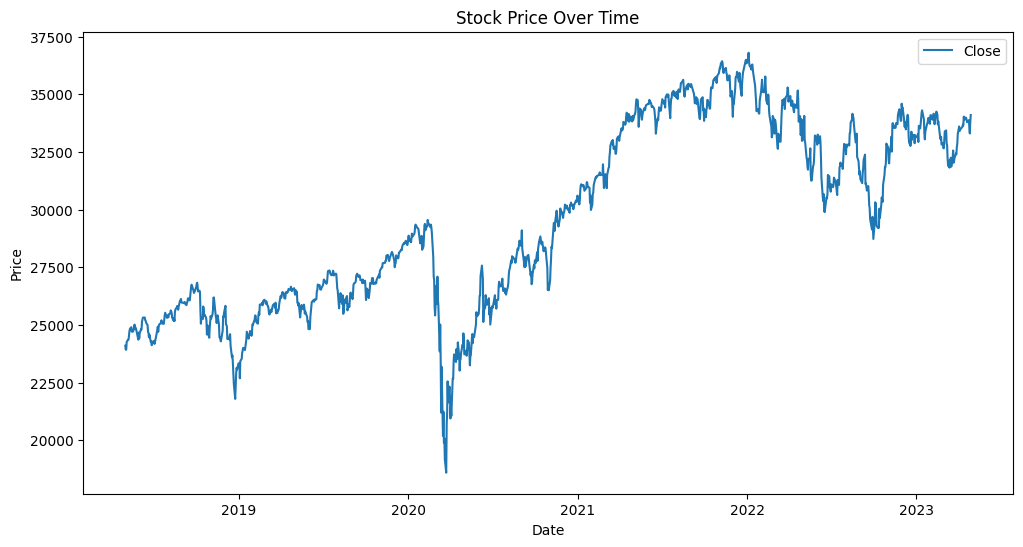

In [88]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

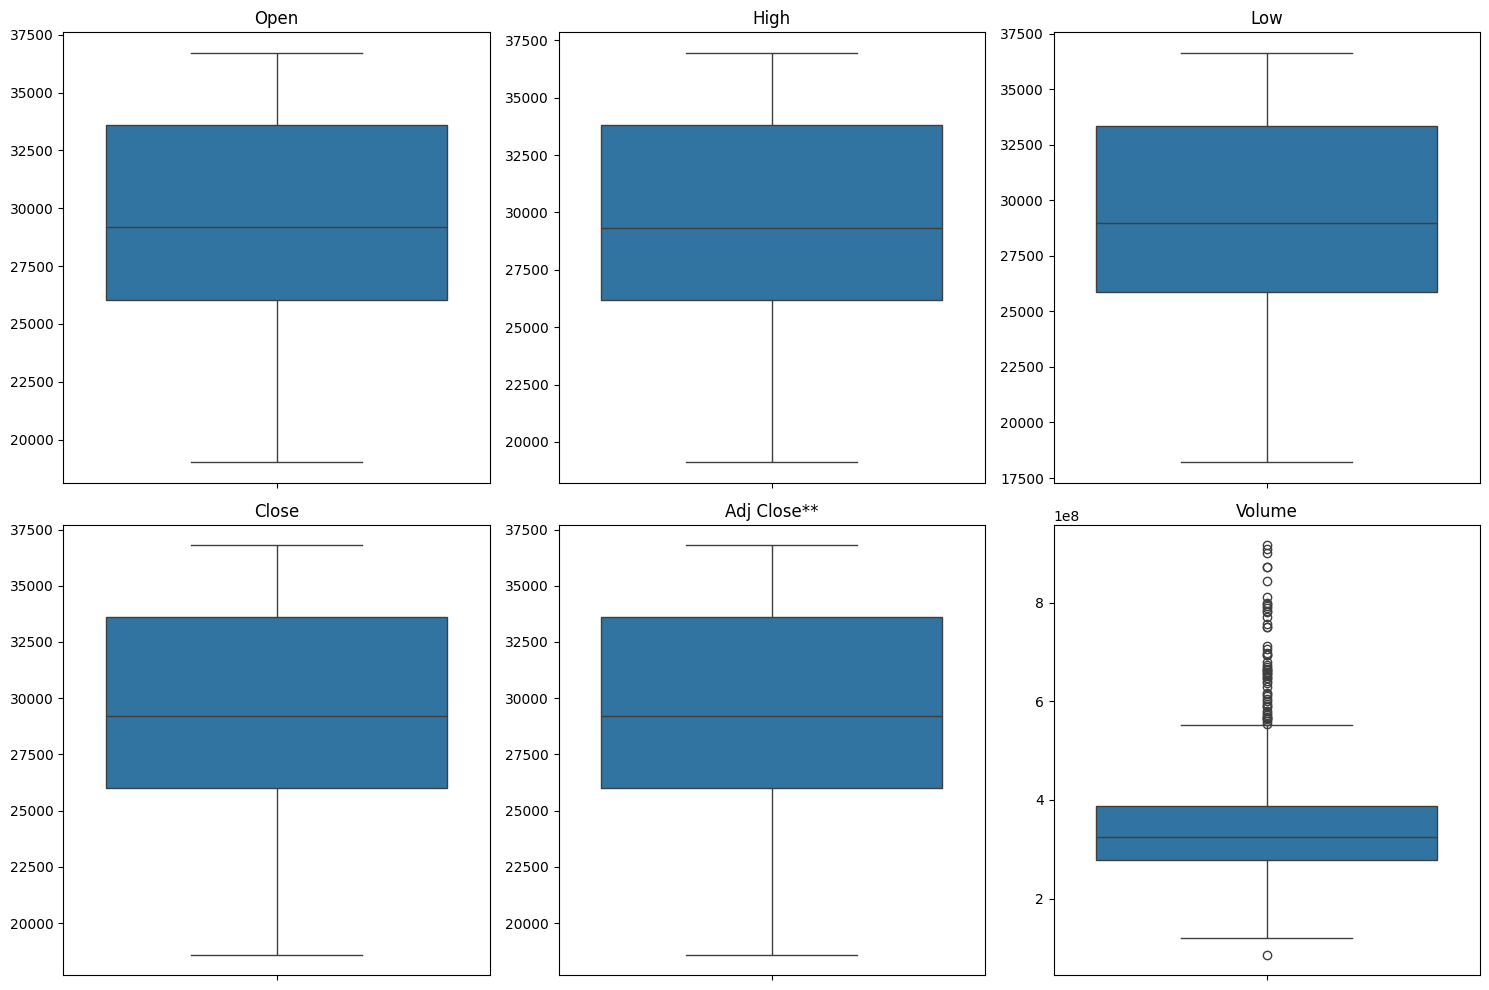

In [89]:
# Check outliers and variations
#import math
#import matplotlib.pyplot as plt
#import seaborn as sns
num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

???
Box plots help us identify outliers, especially in features like volume and closing price.
Features like daily returns may show high variance, indicating periods of increased volatility.
If any box plot has extreme outliers, it may suggest anomalous trading days or incorrect data points.

In [90]:
# Data pre-processing
df.isnull().sum()

Open           0
High           0
Low            0
Close          0
Adj Close**    0
Volume         0
dtype: int64

In [91]:
# Handling if missing values
df.bfill()

,Open,High,Low,Close,Adj Close**,Volume
Date,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000
...,...,...,...,...,...,...
2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000
2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000
2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000


In [92]:
# Calculate moving averages and daily returns
df['7-day MA'] = df['Close'].rolling(window=7).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [93]:
df[df.isna().values==True].drop_duplicates()

,Open,High,Low,Close,Adj Close**,Volume,7-day MA,50-day MA,Daily Return
Date,,,,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000,NaN,NaN,NaN
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000,NaN,NaN,-0.007223
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000,NaN,NaN,0.000216
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000,NaN,NaN,0.013889
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000,NaN,NaN,0.003908
2018-05-08,24341.35,24412.34,24198.34,24360.21,24360.21,344940000,NaN,NaN,0.000119
2018-05-09,24399.18,24586.48,24323.87,24542.54,24542.54,361580000,24210.965714,NaN,0.007485
2018-05-10,24591.66,24794.99,24575.91,24739.53,24739.53,304210000,24302.462857,NaN,0.008026
2018-05-11,24758.64,24868.65,24717.50,24831.17,24831.17,274150000,24431.918571,NaN,0.003704


In [94]:
df = df.dropna()   # Drop all NaN
df

,Open,High,Low,Close,Adj Close**,Volume,7-day MA,50-day MA,Daily Return
Date,,,,,,,,,
2018-07-11,24789.48,24815.16,24663.82,24700.45,24700.45,237370000,24527.417143,24657.5980,-0.008797
2018-07-12,24802.90,24939.97,24802.90,24924.89,24924.89,233150000,24615.661429,24674.1148,0.009086
2018-07-13,24926.07,25043.21,24890.06,25019.41,25019.41,255520000,24736.317143,24696.0034,0.003792
2018-07-16,25025.58,25072.41,24979.64,25064.36,25064.36,231270000,24837.405714,24718.6876,0.001797
2018-07-17,25033.92,25155.39,24989.61,25119.89,25119.89,250450000,24932.178571,24735.8352,0.002215
...,...,...,...,...,...,...,...,...,...
2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000,33888.324286,33096.0934,0.001965
2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000,33837.518571,33089.3246,-0.010172
2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000,33739.617143,33070.4434,-0.006828


???
The stock price exhibits an upward trend with fluctuations.
There are periods of high volatility, suggesting possible external market influences.

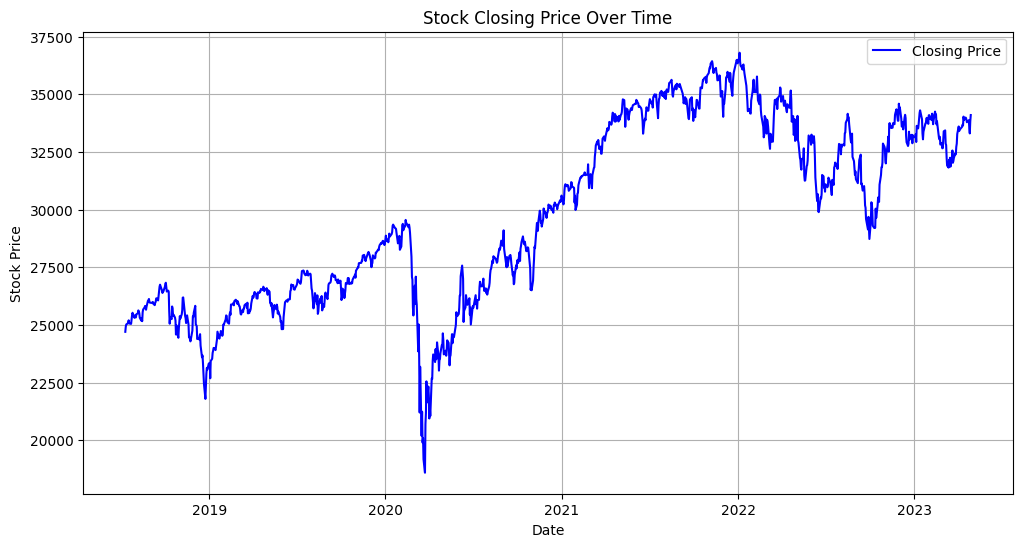

In [96]:
# EDA - explore trends and patterns
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Closing Price Over Time")  
plt.plot(df['Close'], label="Closing Price", color="blue")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()

???
The 7-day MA captures short-term fluctuations, while the 50-day MA provides a smoother long-term trend.
Sharp deviations between moving averages could indicate trend reversals.

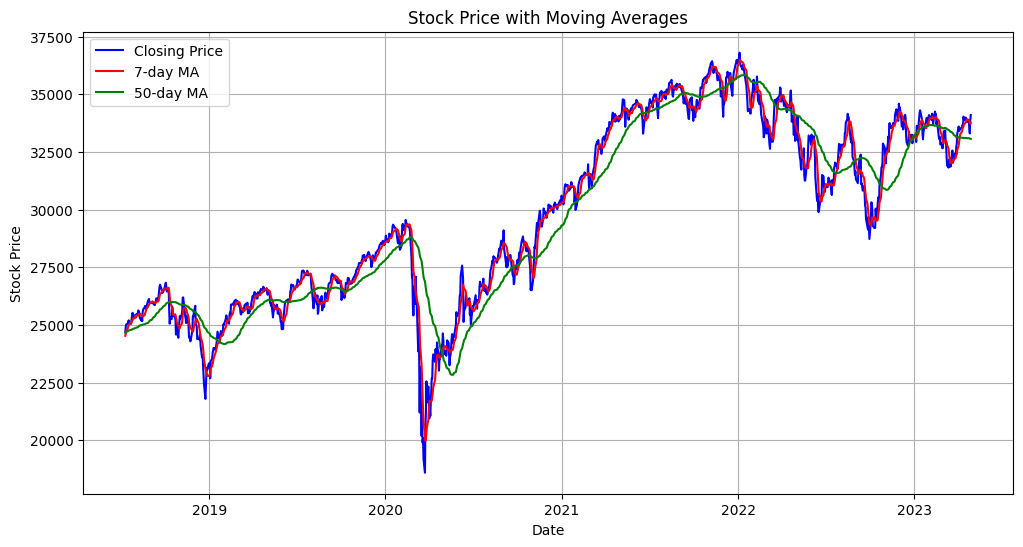

In [97]:
# Smoothen short-term fluctuations with moving averages
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Price with Moving Averages")
plt.plot(df['Close'], label="Closing Price", color="blue")
plt.plot(df['7-day MA'], label="7-day MA", color="red")
plt.plot(df['50-day MA'], label="50-day MA", color="green")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()


In [ ]:
??? Observations
Large spikes indicate high volatility days, often due to earnings reports or major market events.
The stock price shows both positive and negative swings, which is typical of financial markets.

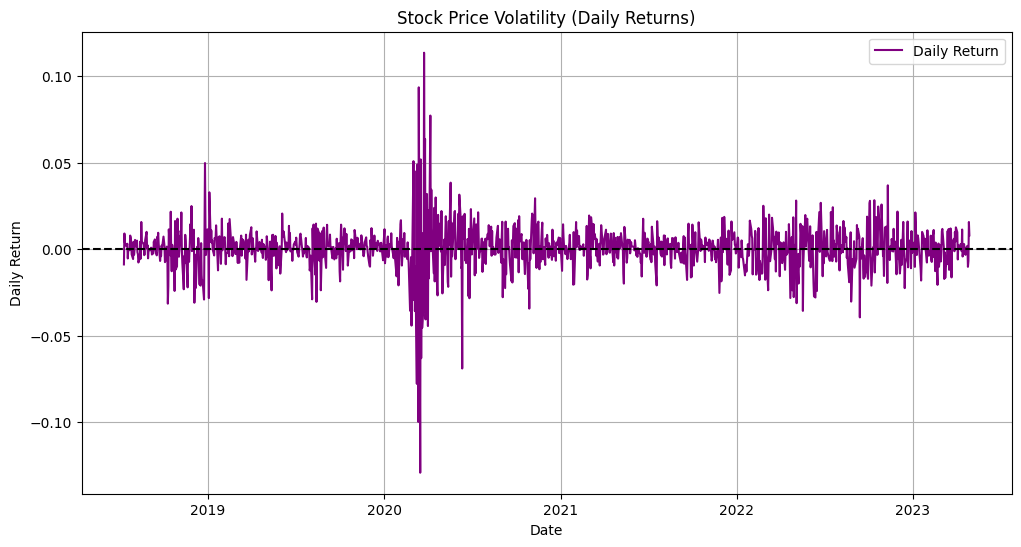

In [99]:
# Analyse Volatility
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Stock Price Volatility (Daily Returns)")
plt.plot(df['Daily Return'], label="Daily Return", color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
# Normailized Data
# from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [15]:
# ADF Test : p-value < 0.05 for stationary data
#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -1.6159587831588444
p-value: 0.47484857865511826
The series is not stationary.


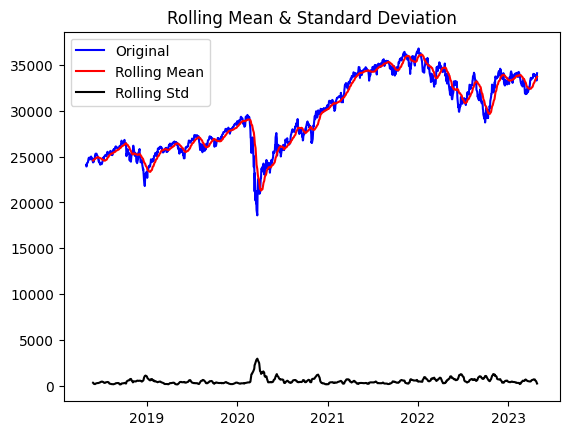

Results of Dickey-Fuller Test:
Test Statistic                   -1.615959
p-value                           0.474849
#Lags Used                        9.000000
Number of Observations Used    1248.000000
Critical Value (1%)              -3.435601
Critical Value (5%)              -2.863859
Critical Value (10%)             -2.568004
dtype: float64


In [16]:
#...ms
close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

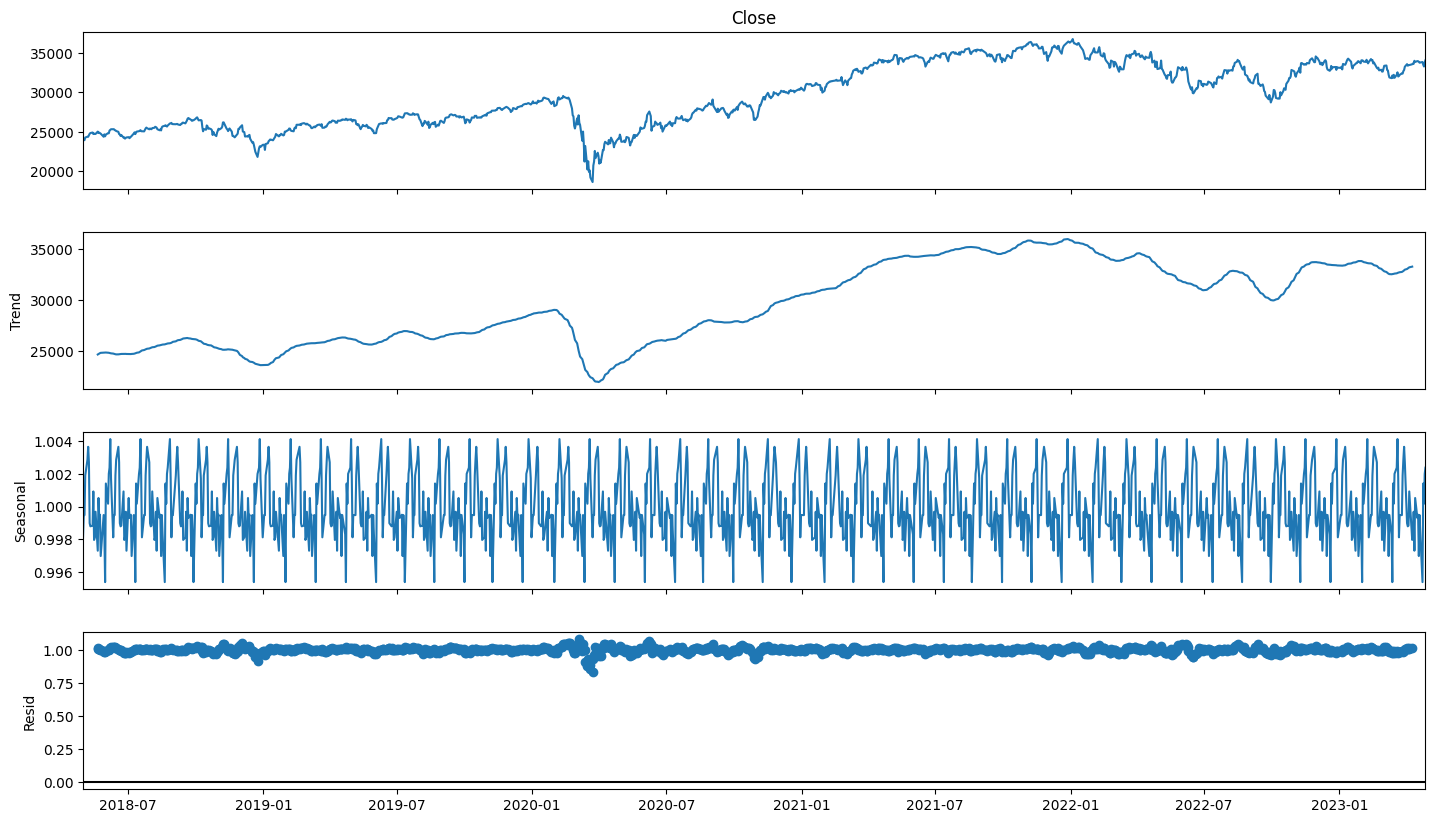

In [17]:
#...
#from statsmodels.tsa.seasonal import seasonal_decompose
#To plot the trend and the seasonality
# We set the period to 28 as we have in average 7*4 = 28 days in a 
# month
# The result below is just to have a first visualization of trend and
# seasonality. Here we take a monthly average but to forecast a stock 
# price, it is more difficult than that to choose the right number of
# days to average on
df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

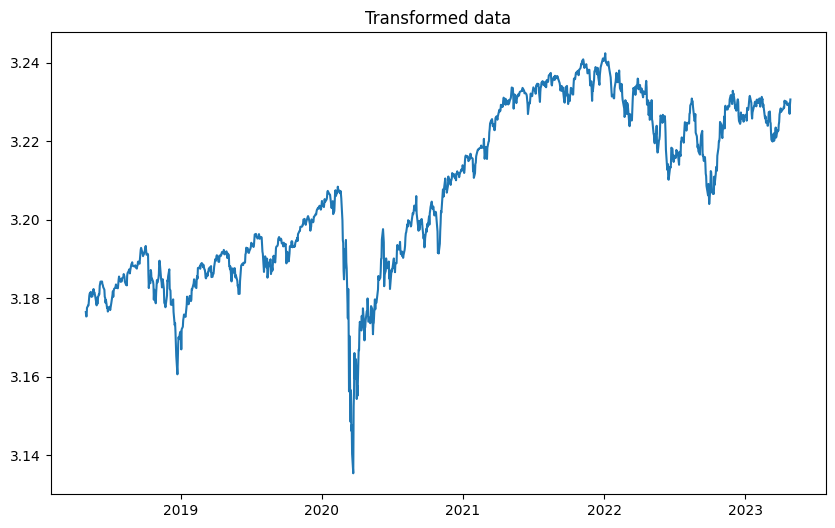

In [18]:
#...
df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

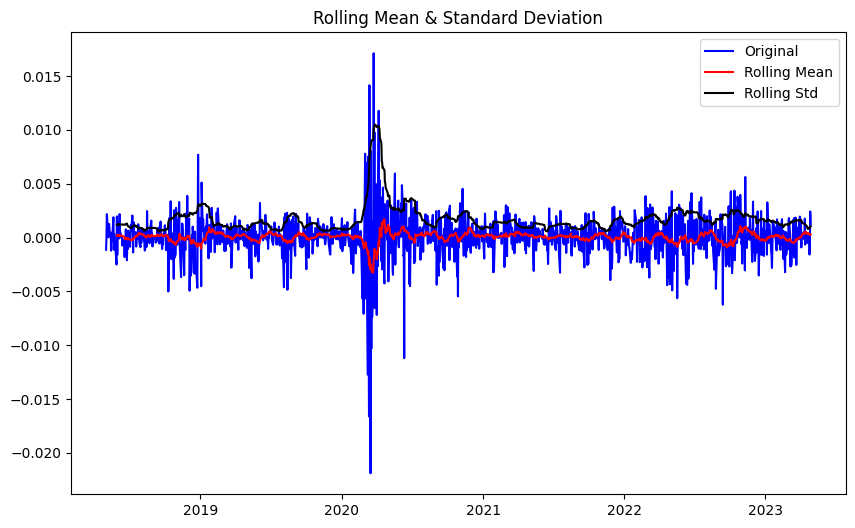

Results of Dickey-Fuller Test:
Test Statistic                -1.078947e+01
p-value                        2.151524e-19
#Lags Used                     8.000000e+00
Number of Observations Used    1.248000e+03
Critical Value (1%)           -3.435601e+00
Critical Value (5%)           -2.863859e+00
Critical Value (10%)          -2.568004e+00
dtype: float64


In [19]:
#...
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

In [20]:
#...ms LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

In [21]:
#...
# choose the number of days on which to base our predictions 
nb_days = 60

n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

In [22]:
#...
#Split the data set between the training set and the test set
test_days = 365 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

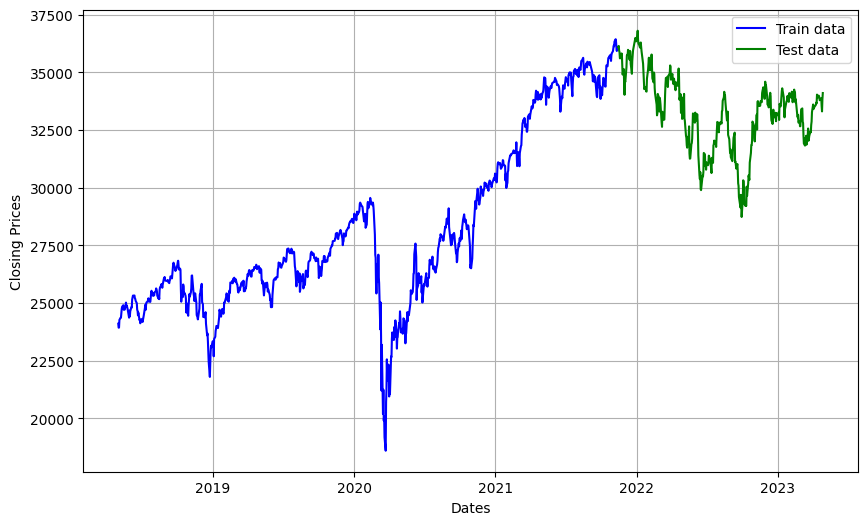

In [23]:
#...
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [24]:
#...
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

In [25]:
#...
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

C:\VCP\PDA3B3\backend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#...
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 1.6007e-05 - mean_absolute_error: 0.0030
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 5.6581e-06 - mean_absolute_error: 0.0014
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 5.5701e-06 - mean_absolute_error: 0.0014
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 5.7433e-06 - mean_absolute_error: 0.0015
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 5.5708e-06 - mean_absolute_error: 0.0014
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 6.0120e-06 - mean_absolute_error: 0.0015
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 6.0098e-06 - mean_absolute_error: 0.0015
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 5.7678e-06 - mean_absolute_error: 0.0016
Epoch 9/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 5.5234e-06 - mean_absolute_error: 0.0014
Epoch 10/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 5.5385e-06 - mean_absolute_error: 0.0014

In [27]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.2306e-06 - mean_absolute_error: 0.0014
Test MSE: 3.230600441384013e-06
Test MAE: 0.001381595036946237


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


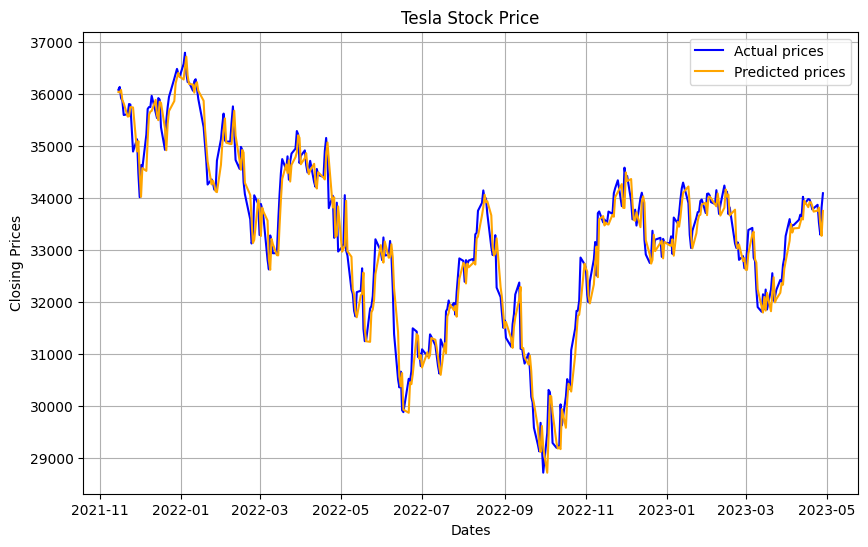

In [28]:
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)


# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
company = 'Tesla'
plt.title(company + ' Stock Price')

plt.legend()

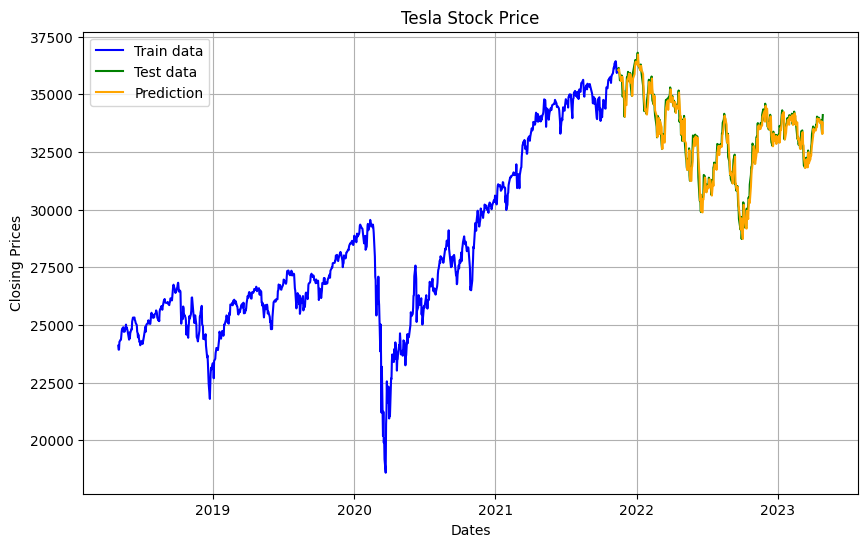

In [29]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [30]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

In [31]:
#...
# Number of days into the future we want to predict
n_steps_out = 10

# choose the number of days on which to base our predictions 
nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

In [32]:
#...
#Split the data set between the training set and the test set
test_days = 365 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [33]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model


In [34]:
#...
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

C:\VCP\PDA3B3\backend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,910 (42.62 KB)

 Trainable params: 10,910 (42.62 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#...
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 6.8375e-06 - mean_absolute_error: 0.0017
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 5.7176e-06 - mean_absolute_error: 0.0014
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 5.7922e-06 - mean_absolute_error: 0.0015
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 6.0108e-06 - mean_absolute_error: 0.0015
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 5.7618e-06 - mean_absolute_error: 0.0015
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 5.8631e-06 - mean_absolute_error: 0.0015
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.8712e-06 - mean_absolute_error: 0.0015
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 5.6480e-06 - mean_absolute_error: 0.0014
Epoch 9/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 5.8813e-06 - mean_absolute_error: 0.0015
Epoch 10/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 5.8549e-06 - mean_absolute_error: 0.0015

In [36]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 3.5539e-06 - mean_absolute_error: 0.0015
Test MSE: 3.553936267053359e-06
Test MAE: 0.0014538312098011374


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


Text(0.5, 1.0, 'Original data vs predictions in the transformed space')

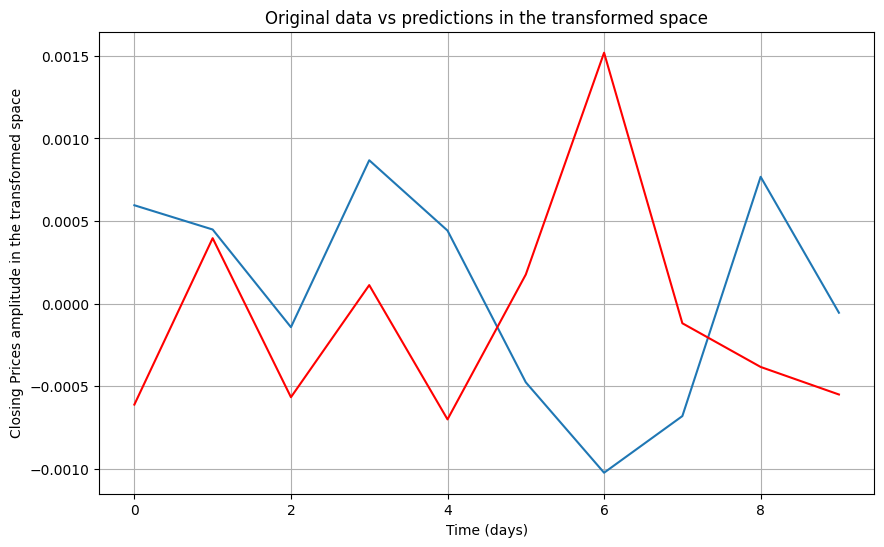

In [37]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')

In [38]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2021-11-15    3.237415
2021-11-16    3.237811
2021-11-17    3.237245
2021-11-18    3.237357
2021-11-19    3.236656
2021-11-22    3.236832
2021-11-23    3.238351
2021-11-24    3.238232
2021-11-26    3.237849
2021-11-29    3.237299
dtype: float64


In [39]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2021-11-15    35626.821090
2021-11-16    35718.332494
2021-11-17    35587.609093
2021-11-18    35613.457662
2021-11-19    35452.296671
2021-11-22    35492.776788
2021-11-23    35843.523349
2021-11-24    35815.955053
2021-11-26    35727.188155
2021-11-29    35600.202390
dtype: float64


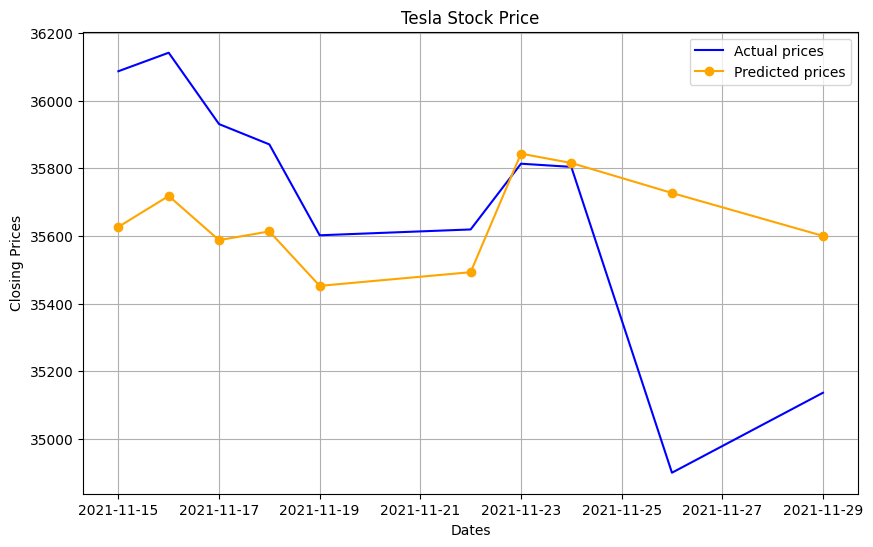

In [40]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [41]:
#
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [42]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [43]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [44]:
#1 LSTM
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=50, batch_size=32)

C:\VCP\PDA3B3\backend\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1044
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0046
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0022
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0017
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0016
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0015
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0015
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0015
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0014
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0014
Epoch 14/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013
Epoch 15/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - lo

In [45]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=50, batch_size=32)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0394
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0067
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0051
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0049
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0045
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0041
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0040
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0037
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0037
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0037
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0031
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0031
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0033
Epoch 14/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0031
Epoch 15/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - lo

???
LSTM(50 units) → Captures long-term dependencies
Dropout(0.2) → Prevents overfitting
Dense Layers → Produces final prediction

In [46]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [47]:
#from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 474.0241540758932


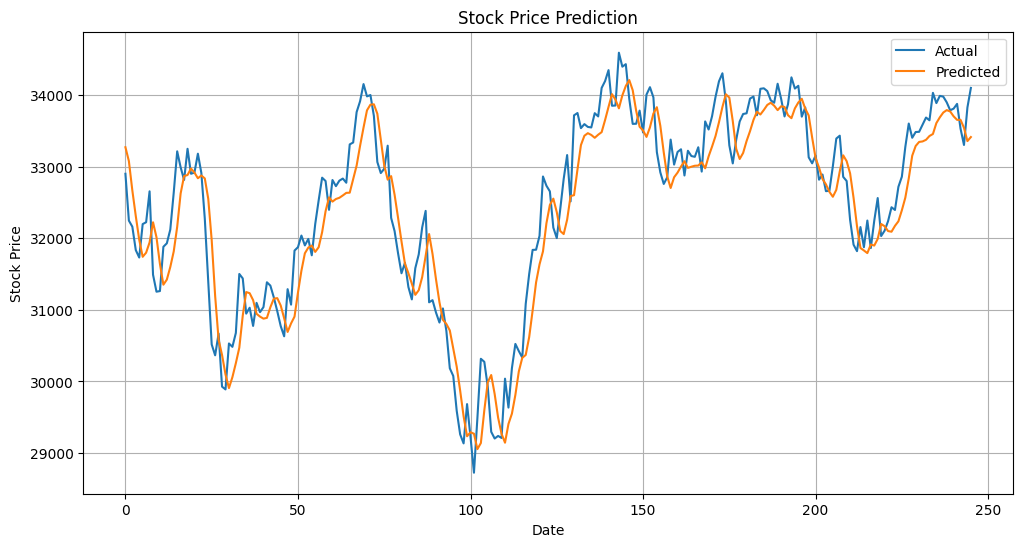

In [48]:
#1
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.